In [1]:
# ================================================================
# CELL 1 — INSTALLS
# ================================================================
!pip install scikit-survival shap optuna xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 8.4 MB/s eta 0:00:00


In [3]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=e0f9f98dd1244452328ef9261db0b94b97fb33de6efcfa0514e3bed7832b304b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
# ================================================================
# CELL 2 — IMPORTS
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap
import optuna
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc
)
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("All imports done.")

All imports done.


In [11]:
# data load 
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ranjanalogendran/metabric-data/METABRIC_RNA_Mutation.csv


In [12]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ranjanalogendran/metabric-data/METABRIC_RNA_Mutation.csv")

print("Shape:", df.shape)
print(df.head(2))

Shape: (1904, 693)
   patient_id  age_at_diagnosis type_of_breast_surgery    cancer_type  \
0           0             75.65             MASTECTOMY  Breast Cancer   
1           2             43.19      BREAST CONSERVING  Breast Cancer   

               cancer_type_detailed cellularity  chemotherapy  \
0  Breast Invasive Ductal Carcinoma         NaN             0   
1  Breast Invasive Ductal Carcinoma        High             0   

  pam50_+_claudin-low_subtype  cohort er_status_measured_by_ihc  ... mtap_mut  \
0                 claudin-low     1.0                   Positve  ...        0   
1                        LumA     1.0                   Positve  ...        0   

   ppp2cb_mut smarcd1_mut nras_mut ndfip1_mut  hras_mut prps2_mut smarcb1_mut  \
0           0           0        0          0         0         0           0   
1           0           0        0          0         0         0           0   

  stmn2_mut  siah1_mut  
0         0          0  
1         0          0  

[

In [13]:
# ================================================================
# CELL 4 — PREPROCESSING
# ================================================================

# --- Survival target ---
df = df.dropna(subset=["overall_survival_months", "overall_survival"])
df = df[df["overall_survival_months"] > 0]

y_structured = Surv.from_arrays(
    event=df["overall_survival"].astype(bool),
    time=df["overall_survival_months"]
)

# --- Drop non-feature columns ---
drop_cols = [
    "overall_survival_months", "overall_survival",
    "patient_id", "cohort",           # drop cohort — study ID, not biological
    "death_from_cancer"               # drop if present — causes leakage
]
drop_cols = [c for c in drop_cols if c in df.columns]
df_feat = df.drop(columns=drop_cols)

# --- Encode categoricals ---
cat_cols = df_feat.select_dtypes(include=["object"]).columns.tolist()
df_feat = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
df_feat = df_feat.fillna(df_feat.median())

# --- Variance threshold (remove near-zero variance) ---
selector = VarianceThreshold(threshold=0.01)
X_sel = selector.fit_transform(df_feat)
selected_cols = df_feat.columns[selector.get_support()].tolist()
X_reduced = pd.DataFrame(X_sel, columns=selected_cols)

# --- Keep top 200 features by variance ---
variances = X_reduced.var().sort_values(ascending=False)
top_cols = variances.head(200).index.tolist()
X_reduced = X_reduced[top_cols]

print("Final feature matrix:", X_reduced.shape)
print("Features:", X_reduced.columns.tolist()[:10], "...")

Final feature matrix: (1903, 200)
Features: ['tumor_size', 'age_at_diagnosis', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'mmp1', 'peg3', 'ryr2', 'sik2', 'rad50'] ...


In [14]:
# ================================================================
# CELL 5 — TRAIN TEST SPLIT + SCALING
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_structured,
    test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_reduced.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_reduced.columns
)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (1522, 200)
Test: (381, 200)


In [15]:
# ================================================================
# CELL 6 — COX PH MODEL
# ================================================================
print("Training Cox PH...")
cox = CoxPHSurvivalAnalysis(alpha=0.1)
cox.fit(X_train_scaled, y_train)

cox_pred = cox.predict(X_test_scaled)
c_index_cox = concordance_index_censored(
    y_test["event"], y_test["time"], cox_pred
)[0]

times = np.linspace(
    np.percentile(y_train["time"], 5),
    np.percentile(y_train["time"], 95),
    100
)

cox_surv = np.asarray([
    [fn(t) for t in times]
    for fn in cox.predict_survival_function(X_test_scaled)
])
ibs_cox = integrated_brier_score(y_train, y_test, cox_surv, times)
auc_cox, _ = cumulative_dynamic_auc(y_train, y_test, cox_pred, times=[60])

print(f"Cox C-index : {c_index_cox:.4f}")
print(f"Cox IBS     : {ibs_cox:.4f}")
print(f"Cox 5yr AUC : {auc_cox[0]:.4f}")

Training Cox PH...
Cox C-index : 0.6630
Cox IBS     : 0.1315
Cox 5yr AUC : 0.6905


In [16]:
# ================================================================
# CELL 7 — RSF WITH BAYESIAN OPTIMIZATION
# ================================================================
print("Optimizing RSF...")
kf = KFold(n_splits=3, shuffle=True, random_state=42)

def rsf_objective(trial):
    rsf = RandomSurvivalForest(
        n_estimators=trial.suggest_int("n_estimators", 100, 300),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 5, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 8),
        n_jobs=-1, random_state=42
    )
    c_indices = []
    for tr_idx, val_idx in kf.split(X_train_scaled):
        X_tr  = X_train_scaled.iloc[tr_idx]
        X_val = X_train_scaled.iloc[val_idx]
        y_tr  = y_train[tr_idx]
        y_val = y_train[val_idx]
        rsf.fit(X_tr, y_tr)
        preds = rsf.predict(X_val)
        c_indices.append(
            concordance_index_censored(y_val["event"], y_val["time"], preds)[0]
        )
    return np.mean(c_indices)

study_rsf = optuna.create_study(direction="maximize")
study_rsf.optimize(rsf_objective, n_trials=10)

print("Best RSF params:", study_rsf.best_params)

rsf_final = RandomSurvivalForest(
    **study_rsf.best_params,
    n_jobs=-1, random_state=42
)
rsf_final.fit(X_train_scaled, y_train)

rsf_pred = rsf_final.predict(X_test_scaled)
c_index_rsf = concordance_index_censored(
    y_test["event"], y_test["time"], rsf_pred
)[0]

rsf_surv = np.asarray([
    [fn(t) for t in times]
    for fn in rsf_final.predict_survival_function(X_test_scaled)
])
ibs_rsf = integrated_brier_score(y_train, y_test, rsf_surv, times)
auc_rsf, _ = cumulative_dynamic_auc(y_train, y_test, rsf_pred, times=[60])

print(f"RSF C-index : {c_index_rsf:.4f}")
print(f"RSF IBS     : {ibs_rsf:.4f}")
print(f"RSF 5yr AUC : {auc_rsf[0]:.4f}")

Optimizing RSF...
Best RSF params: {'n_estimators': 243, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 6}
RSF C-index : 0.6841
RSF IBS     : 0.1235
RSF 5yr AUC : 0.6573


In [17]:
# ================================================================
# CELL 8 — XGBOOST SURVIVAL
# ================================================================
print("Optimizing XGBoost...")

y_train_xgb = np.where(y_train["event"], y_train["time"], -y_train["time"])
y_test_xgb  = np.where(y_test["event"],  y_test["time"],  -y_test["time"])
dtrain = xgb.DMatrix(X_train_scaled, label=y_train_xgb)
dtest  = xgb.DMatrix(X_test_scaled,  label=y_test_xgb)

def xgb_objective(trial):
    params = {
        "objective": "survival:cox",
        "eval_metric": "cox-nloglik",
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "eta": trial.suggest_float("eta", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "verbosity": 0, "seed": 42
    }
    n_rounds = trial.suggest_int("n_rounds", 50, 200)
    c_indices = []
    for tr_idx, val_idx in kf.split(X_train_scaled):
        X_tr  = X_train_scaled.iloc[tr_idx]
        X_val = X_train_scaled.iloc[val_idx]
        y_tr  = y_train_xgb[tr_idx]
        y_va  = y_train_xgb[val_idx]
        y_val_struct = y_train[val_idx]
        dtr  = xgb.DMatrix(X_tr,  label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_va)
        model = xgb.train(params, dtr, num_boost_round=n_rounds, verbose_eval=False)
        preds = model.predict(dval)
        c_indices.append(
            concordance_index_censored(
                y_val_struct["event"], y_val_struct["time"], preds
            )[0]
        )
    return np.mean(c_indices)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=10)

best_xgb = study_xgb.best_params
n_rounds_final = best_xgb.pop("n_rounds")
best_xgb.update({
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "verbosity": 0, "seed": 42
})

xgb_model = xgb.train(best_xgb, dtrain, num_boost_round=n_rounds_final)
xgb_pred  = xgb_model.predict(dtest)

c_index_xgb = concordance_index_censored(
    y_test["event"], y_test["time"], xgb_pred
)[0]
auc_xgb, _ = cumulative_dynamic_auc(y_train, y_test, xgb_pred, times=[60])

print(f"XGBoost C-index : {c_index_xgb:.4f}")
print(f"XGBoost 5yr AUC : {auc_xgb[0]:.4f}")

Optimizing XGBoost...
XGBoost C-index : 0.6847
XGBoost 5yr AUC : 0.6269


In [18]:
# ================================================================
# CELL 9 — RESULTS TABLE + BOOTSTRAP CI
# ================================================================
results = pd.DataFrame({
    "Model":      ["Cox PH", "RSF", "XGBoost"],
    "C-index":    [round(c_index_cox,4), round(c_index_rsf,4), round(c_index_xgb,4)],
    "IBS":        [round(ibs_cox,4),     round(ibs_rsf,4),     "N/A"],
    "5-Year AUC": [round(auc_cox[0],4),  round(auc_rsf[0],4),  round(auc_xgb[0],4)]
})
print("\n===== FINAL RESULTS TABLE =====")
print(results.to_string(index=False))

# Bootstrap CI for best model
print("\nBootstrap CI for XGBoost C-index...")
np.random.seed(42)
boot_cis = []
for _ in range(1000):
    idx = np.random.choice(len(X_test_scaled), len(X_test_scaled), replace=True)
    X_b = X_test_scaled.iloc[idx]
    y_b = y_test[idx]
    try:
        p = xgb_model.predict(xgb.DMatrix(X_b))
        ci = concordance_index_censored(y_b["event"], y_b["time"], p)[0]
        boot_cis.append(ci)
    except:
        pass

print(f"XGBoost C-index: {c_index_xgb:.4f} "
      f"(95% CI: {np.percentile(boot_cis,2.5):.4f}–{np.percentile(boot_cis,97.5):.4f})")


===== FINAL RESULTS TABLE =====
  Model  C-index     IBS  5-Year AUC
 Cox PH   0.6630  0.1315      0.6905
    RSF   0.6841  0.1235      0.6573
XGBoost   0.6847     N/A      0.6269

Bootstrap CI for XGBoost C-index...
XGBoost C-index: 0.6847 (95% CI: 0.6267–0.7366)


Log-rank p-value: 4.12e-08


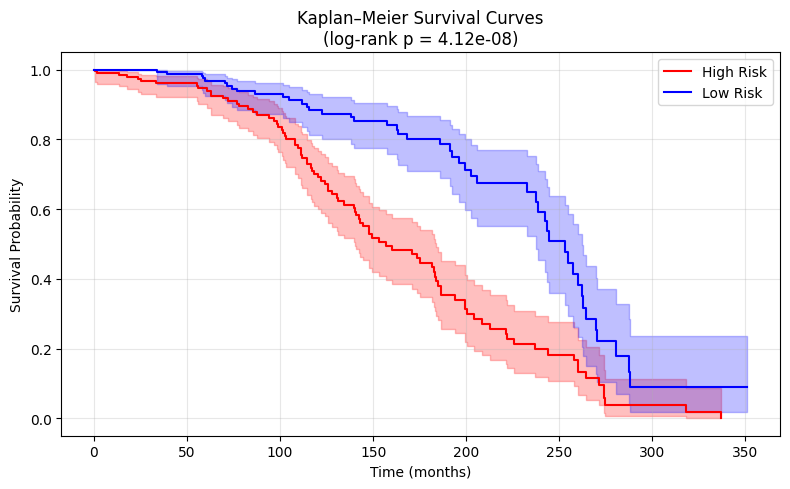

Saved: kaplan_meier.png


In [19]:
# ================================================================
# CELL 10 — KAPLAN MEIER RISK STRATIFICATION
# ================================================================
# Use XGBoost (best model) risk scores
median_risk = np.median(xgb_pred)
high_risk = xgb_pred >= median_risk
low_risk  = xgb_pred <  median_risk

t_high = y_test["time"][high_risk]
e_high = y_test["event"][high_risk]
t_low  = y_test["time"][~high_risk]
e_low  = y_test["event"][~high_risk]

result = logrank_test(t_high, t_low, e_high, e_low)
print(f"Log-rank p-value: {result.p_value:.2e}")

kmf_high = KaplanMeierFitter()
kmf_low  = KaplanMeierFitter()

plt.figure(figsize=(8, 5))
kmf_high.fit(t_high, e_high, label="High Risk")
kmf_high.plot_survival_function(ci_show=True, color="red")
kmf_low.fit(t_low, e_low, label="Low Risk")
kmf_low.plot_survival_function(ci_show=True, color="blue")

plt.title(f"Kaplan–Meier Survival Curves\n(log-rank p = {result.p_value:.2e})")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kaplan_meier.png", dpi=150)
plt.show()
print("Saved: kaplan_meier.png")

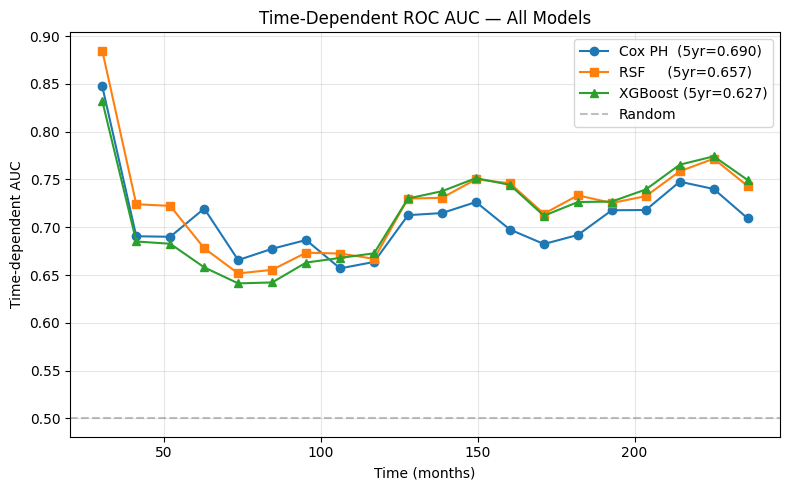

Saved: timedep_auc.png


In [20]:
# ================================================================
# CELL 11 — TIME DEPENDENT AUC CURVE
# ================================================================
time_points = np.linspace(
    np.percentile(y_train["time"], 10),
    np.percentile(y_train["time"], 90),
    20
)

auc_cox_td, _ = cumulative_dynamic_auc(y_train, y_test, cox_pred,  time_points)
auc_rsf_td, _ = cumulative_dynamic_auc(y_train, y_test, rsf_pred,  time_points)
auc_xgb_td, _ = cumulative_dynamic_auc(y_train, y_test, xgb_pred,  time_points)

plt.figure(figsize=(8, 5))
plt.plot(time_points, auc_cox_td, label=f"Cox PH  (5yr={auc_cox[0]:.3f})", marker="o")
plt.plot(time_points, auc_rsf_td, label=f"RSF     (5yr={auc_rsf[0]:.3f})", marker="s")
plt.plot(time_points, auc_xgb_td, label=f"XGBoost (5yr={auc_xgb[0]:.3f})", marker="^")
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.5, label="Random")
plt.xlabel("Time (months)")
plt.ylabel("Time-dependent AUC")
plt.title("Time-Dependent ROC AUC — All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("timedep_auc.png", dpi=150)
plt.show()
print("Saved: timedep_auc.png")

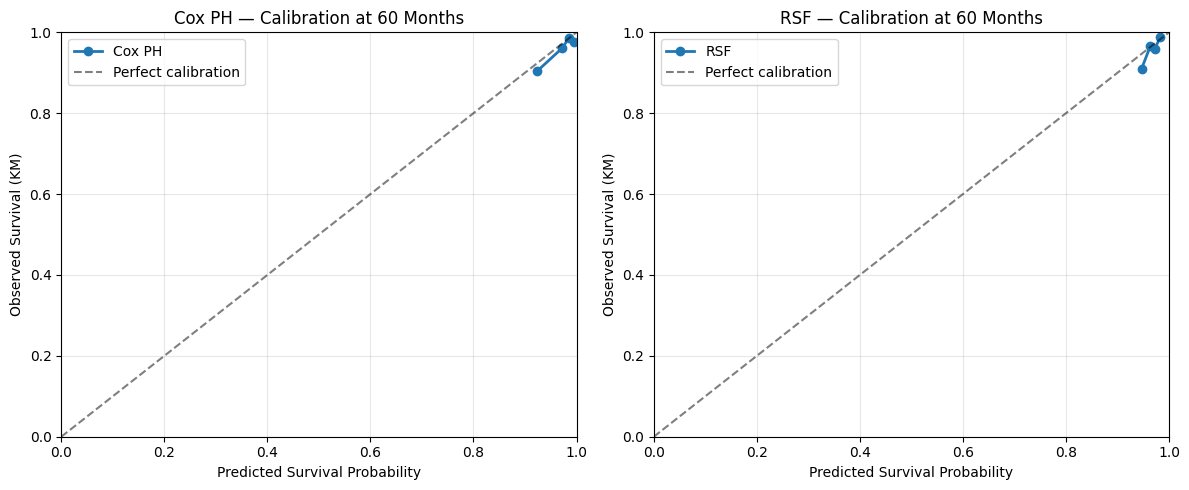

Saved: calibration_curves.png


In [21]:
# ================================================================
# CELL 12 — CALIBRATION CURVES
# ================================================================
def calibration_curve_survival(model, X, y, time_point, n_bins=4):
    surv_fns = model.predict_survival_function(X)
    pred_probs = np.array([fn(time_point) for fn in surv_fns])
    bin_edges = np.unique(np.percentile(pred_probs, np.linspace(0, 100, n_bins+1)))
    mean_predicted, mean_observed = [], []
    for i in range(len(bin_edges) - 1):
        mask = (pred_probs >= bin_edges[i]) & (pred_probs < bin_edges[i+1])
        if mask.sum() < 5:
            continue
        mean_predicted.append(pred_probs[mask].mean())
        y_bin = y[mask]
        times_km, surv_km = kaplan_meier_estimator(y_bin["event"], y_bin["time"])
        idx = np.searchsorted(times_km, time_point, side="right") - 1
        obs = 1.0 if idx < 0 else (surv_km[-1] if idx >= len(surv_km) else surv_km[idx])
        mean_observed.append(obs)
    return np.array(mean_predicted), np.array(mean_observed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (model, label) in zip(axes, [(cox, "Cox PH"), (rsf_final, "RSF")]):
    pred, obs = calibration_curve_survival(model, X_test_scaled, y_test, 60)
    ax.plot(pred, obs, marker="o", linewidth=2, label=label)
    ax.plot([0,1],[0,1], "k--", alpha=0.5, label="Perfect calibration")
    ax.set_title(f"{label} — Calibration at 60 Months")
    ax.set_xlabel("Predicted Survival Probability")
    ax.set_ylabel("Observed Survival (KM)")
    ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend()
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=150)
plt.show()
print("Saved: calibration_curves.png")

Computing SHAP values...


PermutationExplainer explainer: 101it [35:56, 21.57s/it]                         


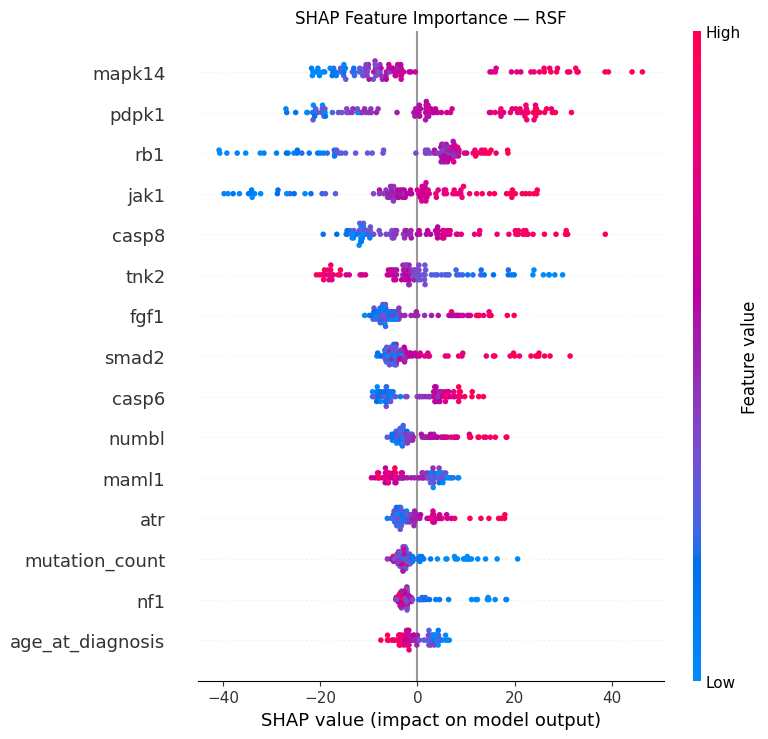

Saved: shap_summary.png


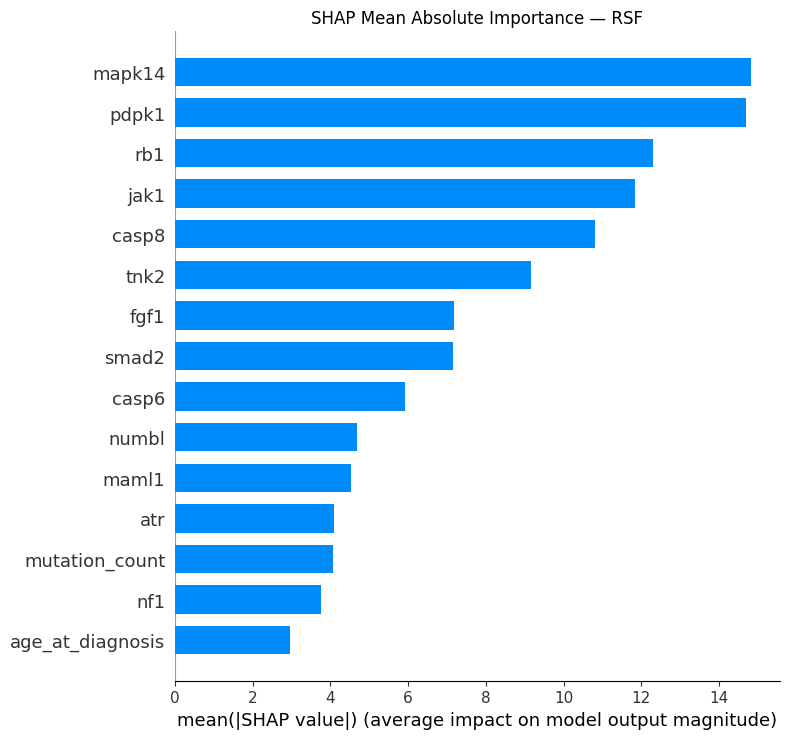

Saved: shap_bar.png


In [22]:
# ================================================================
# CELL 13 — SHAP (RSF)
# ================================================================
print("Computing SHAP values...")

sample_size = min(100, X_test_scaled.shape[0])
X_shap_df = X_test_scaled.iloc[:sample_size]

masker = shap.maskers.Independent(X_shap_df, max_samples=50)
explainer = shap.PermutationExplainer(rsf_final.predict, masker)
shap_values = explainer(X_shap_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_df, max_display=15, show=False)
plt.title("SHAP Feature Importance — RSF")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary.png")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_df, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Mean Absolute Importance — RSF")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_bar.png")

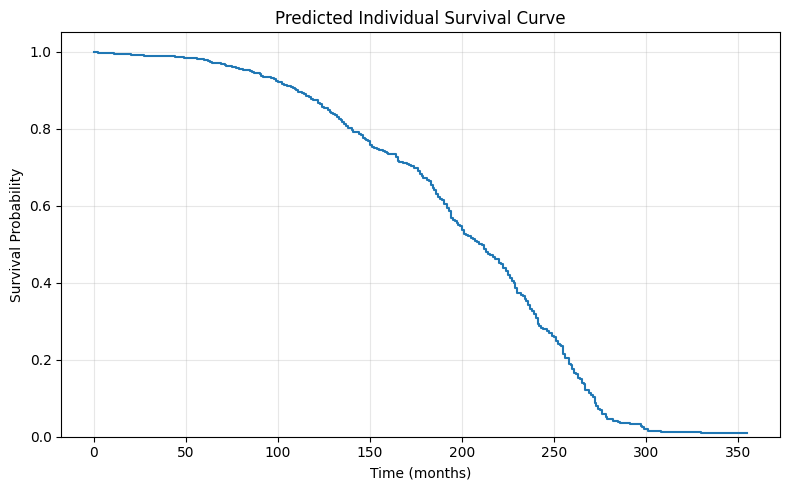

Saved: individual_survival.png


In [23]:
# ================================================================
# CELL 14 — INDIVIDUAL SURVIVAL PREDICTION
# ================================================================
def predict_individual(age, tumor_grade, chemo, er_positive):
    patient = pd.DataFrame([{
        "age_at_diagnosis": age,
        "tumor_grade": tumor_grade,
        "chemotherapy_Yes": chemo,
        "er_status_measured_by_ihc_Positive": er_positive
    }])
    patient = patient.reindex(columns=X_reduced.columns, fill_value=0)
    patient_scaled = pd.DataFrame(
        scaler.transform(patient),
        columns=X_reduced.columns
    )
    surv_fn = rsf_final.predict_survival_function(patient_scaled)[0]

    # Deduplicate time points
    seen = {}
    for t, s in zip(surv_fn.x, surv_fn.y):
        seen[round(t)] = s
    clean_times = sorted(seen.keys())
    clean_probs = [seen[t] for t in clean_times]

    plt.figure(figsize=(8, 5))
    plt.step(clean_times, clean_probs, where="post")
    plt.xlabel("Time (months)")
    plt.ylabel("Survival Probability")
    plt.title("Predicted Individual Survival Curve")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("individual_survival.png", dpi=150)
    plt.show()
    print("Saved: individual_survival.png")

# Example patient
predict_individual(age=52, tumor_grade=2, chemo=1, er_positive=1)

In [24]:
# ================================================================
# CELL 15 — SAVE ALL MODELS
# ================================================================
import joblib

joblib.dump(rsf_final,  "rsf_final.pkl")
joblib.dump(cox,        "cox_model.pkl")
joblib.dump(scaler,     "scaler.pkl")
xgb_model.save_model(   "xgb_model.json")
X_reduced.to_csv(       "X_reduced_columns.csv", index=False)

print("All models saved. Download from Kaggle output tab.")

All models saved. Download from Kaggle output tab.
